In [18]:
import sys
from pyprojroot import here
sys.path.insert(0, str(here()))

In [19]:
from src.segmentation import load_segmentation_model, segment_image

In [20]:
import os
import torch
from tqdm import tqdm

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = here() / "data/sky_segmentation_unet_model.pth"

In [22]:
model = load_segmentation_model(model_path, device)

In [23]:
images_dir = here() / "data/synthetic_dataset/images"
masks_dir = here() / "data/synthetic_dataset/predicted_masks"
masks_dir.mkdir(parents=True, exist_ok=True)

In [24]:
image_files = sorted([
    f for f in os.listdir(images_dir) 
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

In [25]:
print(f"Segmenting {len(image_files)} query images...")
for file_name in tqdm(image_files, desc="Segmenting Query Images"):
    segment_image(
        model=model,
        img_path=os.path.join(images_dir, file_name),
        mask_output_path=os.path.join(masks_dir, file_name),
        device=device
    )
print("✓ Sky segmentation complete!")

Segmenting 300 query images...


Segmenting Query Images: 100%|██████████| 300/300 [00:25<00:00, 11.70it/s]

✓ Sky segmentation complete!


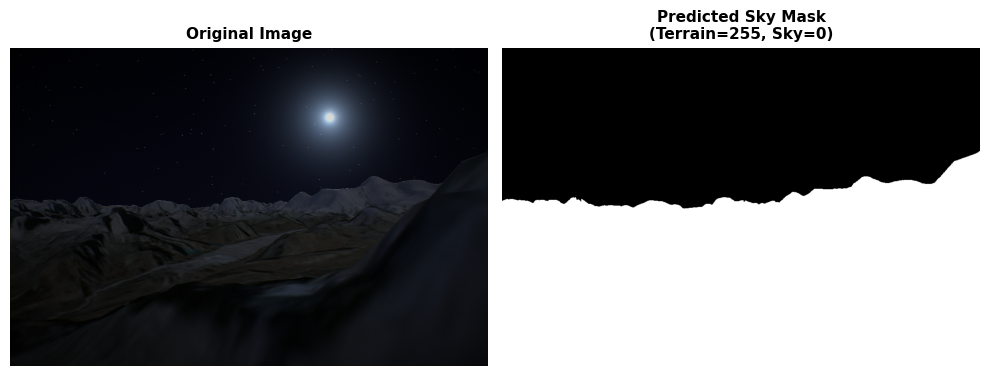

In [26]:
import matplotlib.pyplot as plt
from PIL import Image

sample_id = 0
sample_img = Image.open(images_dir / f"sample_{sample_id:04d}.png")
sample_mask = Image.open(masks_dir / f"sample_{sample_id:04d}.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_img)
axes[0].set_title("Original Image", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(sample_mask, cmap='gray')
axes[1].set_title("Predicted Sky Mask\n(Terrain=255, Sky=0)", fontsize=11, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()